In [4]:
import kagglehub
import pandas as pd
import os

# Download the 50K Reviews dataset (This one has the 'sentiment' column you need)
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

# Find the CSV file in the downloaded path
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

# Load into a DataFrame
df = pd.read_csv(full_path)

print("Dataset Loaded Successfully!")
print(df.head())

100%|██████████| 25.7M/25.7M [00:00<00:00, 157MB/s]

Extracting files...


Dataset Loaded Successfully!
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


Missing values in dataset:
 review       0
sentiment    0
dtype: int64


/tmp/ipykernel_942/3863467044.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='Set2')


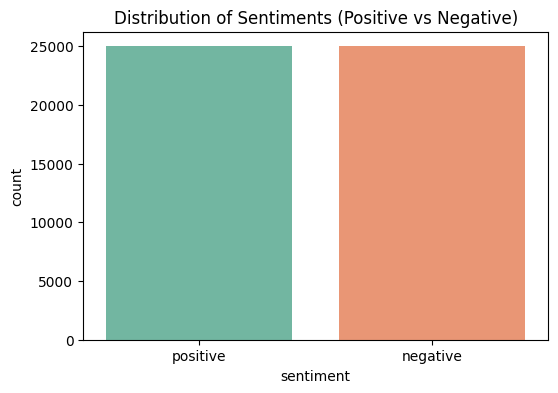

Raw Sample Review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check for missing values
print("Missing values in dataset:\n", df.isnull().sum())

# Class distribution analysis
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df, palette='Set2')
plt.title('Distribution of Sentiments (Positive vs Negative)')
plt.show()

# Observe the raw text of the first review
print("Raw Sample Review:")
print(df['review'].iloc[0][:500])

In [9]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources for Colab
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [10]:
def preprocess_text(text):
    # 1. Lowercasing
    text = text.lower()
    # 2. Removing HTML tags (like <br>)
    text = re.sub(r'<.*?>', '', text)
    # 3. Removing URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # 4. Removing punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 5. Tokenization
    tokens = word_tokenize(text)
    # 6. Removing Stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [w for w in tokens if w not in stop_words]
    # 7. Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return " ".join(tokens)

# Working on a subset of 10,000 to keep it efficient
df_subset = df.sample(10000, random_state=42).copy()
print("Cleaning text... please wait.")
df_subset['cleaned_review'] = df_subset['review'].apply(preprocess_text)

print("Cleaning Complete!")
df_subset[['review', 'cleaned_review']].head()

Cleaning text... please wait.
Cleaning Complete!


,review,cleaned_review
33553,I really liked this Summerslam due to the look...,really liked summerslam due look arena curtain...
9427,Not many television shows appeal to quite as m...,many television show appeal quite many differe...
199,The film quickly gets to a major chase scene w...,film quickly get major chase scene ever increa...
12447,Jane Austen would definitely approve of this o...,jane austen would definitely approve onegwynet...
39489,Expectations were somewhat high for me when I ...,expectation somewhat high went see movie thoug...


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF with a limit of 5000 features
tfidf = TfidfVectorizer(max_features=5000)

# Create the Feature Matrix (X) and Target Vector (y)
X = tfidf.fit_transform(df_subset['cleaned_review']).toarray()
y = df_subset['sentiment'].map({'positive': 1, 'negative': 0})

print(f"Feature Matrix Shape: {X.shape}")

Feature Matrix Shape: (10000, 5000)


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split data: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define models
models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier()
}

# Iterate, train, and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n--- {name} Performance ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))


--- Logistic Regression Performance ---
Accuracy: 0.8705
              precision    recall  f1-score   support

           0       0.89      0.84      0.87       999
           1       0.85      0.90      0.87      1001

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000


--- Naive Bayes Performance ---
Accuracy: 0.8480
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       999
           1       0.85      0.85      0.85      1001

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000


--- Decision Tree Performance ---
Accuracy: 0.7040
              precision    recall  f1-score   support

           0       0.71      0.69      0.70       999
           1       0.70      0.72      0.71      1001

    accuracy          